Processando a série histórica na nuvem do Earth Engine...
✅ Ano 2016 processado.
✅ Ano 2017 processado.
✅ Ano 2018 processado.
✅ Ano 2019 processado.
✅ Ano 2020 processado.
✅ Ano 2021 processado.
✅ Ano 2022 processado.
✅ Ano 2023 processado.
✅ Ano 2024 processado.
✅ Ano 2025 processado.

📊 Planilha 'ndvi_valores_finais_tcc.csv' salva com sucesso!


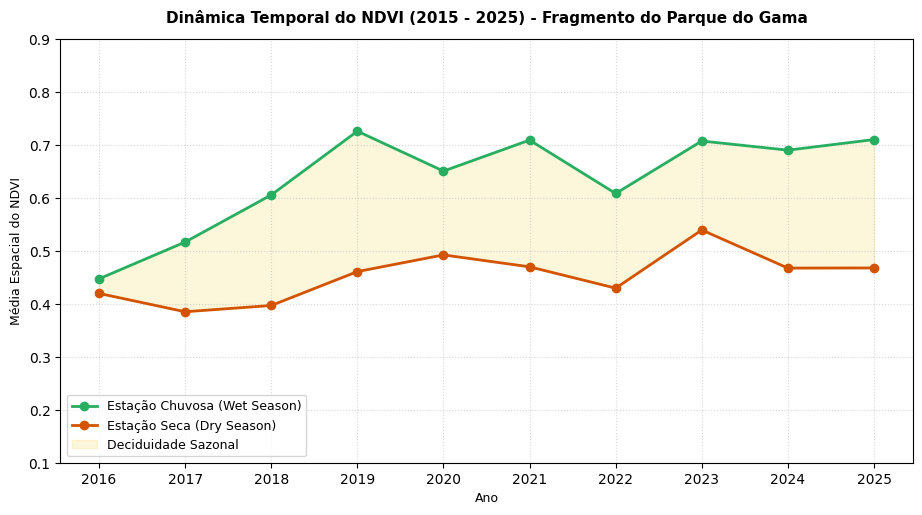

🖼️ gráfico gerado


In [15]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


datas_seca = {
    2016: '2016-08-11', 2017: '2017-09-25',
    2018: '2018-09-05', # cena de 2018 
    2019: '2019-09-15', 2020: '2020-09-29', 2021: '2021-08-25', 
    2022: '2022-08-30', 2023: '2023-08-05', 2024: '2024-09-03', 
    2025: '2025-09-15'
}

datas_chuva = {
    2016: '2016-11-09', 2017: '2017-11-14', 
    2018: '2018-11-29', # cena de 2018 
    2019: '2019-12-29', 2020: '2020-11-08', 2021: '2021-01-27',
    2022: '2022-11-13', 2023: '2023-12-13', 2024: '2024-12-07',
    2025: '2025-03-07'
}

data_records = []
years_all = sorted(list(set(list(datas_seca.keys()) + list(datas_chuva.keys()))))

print("Processando a série histórica na nuvem do Earth Engine...")

for year in years_all:
    date_dry = datas_seca.get(year)
    date_rain = datas_chuva.get(year)
    
    mean_dry = None
    mean_rain = None
    
    
    # SECA: Ajuste de coleção para 2015 e 2018 (L1C/Top of Atmosphere)
    if date_dry:
        colecao_seca = 'COPERNICUS/S2' if year in [2015, 2018] else 'COPERNICUS/S2_SR_HARMONIZED'
        # Evita problemas de fuso horário recuando 1 dia nas imagens críticas
        start_dry_filter = '2015-09-15' if year == 2015 else ('2018-09-04' if year == 2018 else date_dry)
        
        try:
            img_dry = (ee.ImageCollection(colecao_seca)
                       .filterBounds(roi)
                       .filterDate(start_dry_filter, ee.Date(date_dry).advance(2, 'day'))
                       .map(mask_s2_clouds)
                       .map(calculate_ndvi)
                       .first()
                       .clip(roi))
            stats_dry = img_dry.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_dry = stats_dry.get('NDVI')
        except Exception as e:
            print(f"⚠️ Alerta na Seca de {year}: Verificar a janela de dados no GEE.")


    # CHUVA: Ajuste de coleção para 2016, 2017 e 2018
    if date_rain:
        colecao_chuva = 'COPERNICUS/S2' if year <= 2018 else 'COPERNICUS/S2_SR_HARMONIZED'
        start_rain_filter = '2018-11-28' if year == 2018 else date_rain
        
        try:
            img_rain = (ee.ImageCollection(colecao_chuva)
                        .filterBounds(roi)
                        .filterDate(start_rain_filter, ee.Date(date_rain).advance(2, 'day'))
                        .map(mask_s2_clouds)
                        .map(calculate_ndvi)
                        .first()
                        .clip(roi))
            stats_rain = img_rain.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_rain = stats_rain.get('NDVI')
        except Exception as e:
            print(f"⚠️ Alerta na Chuva de {year}: Verificar a janela de dados no GEE.")
            
    # Armazenando os registros válidos
    if mean_dry is not None or mean_rain is not None:
        data_records.append({
            'Year': year,
            'NDVI_Rainy': mean_rain if mean_rain is not None else np.nan,
            'NDVI_Dry': mean_dry if mean_dry is not None else np.nan,
            'NDVI_Drop': (mean_rain - mean_dry) if (mean_rain is not None and mean_dry is not None) else np.nan,
            'Date_Rainy': date_rain if date_rain else 'Sem Informação',
            'Date_Dry': date_dry if date_dry else 'Sem Informação'
        })
        print(f"✅ Ano {year} processado.")


# SALVAR PLANILHA DE DADOS (PANDAS)
df_tcc = pd.DataFrame(data_records)
df_tcc.to_csv("ndvi_valores_finais_tcc.csv", index=False)
print("\n📊 Planilha 'ndvi_valores_finais_tcc.csv' salva com sucesso!")


# PLOTAR GRÁFICO DE LINHAS DA SAZONALIDADE
plt.figure(figsize=(11, 5.5))

df_rain_plot = df_tcc.dropna(subset=['NDVI_Rainy'])
df_dry_plot = df_tcc.dropna(subset=['NDVI_Dry'])

# Plot das linhas de tendência histórica
plt.plot(df_rain_plot['Year'], df_rain_plot['NDVI_Rainy'], marker='o', color='#27ae60', linewidth=2, label='Estação Chuvosa (Wet Season)')
plt.plot(df_dry_plot['Year'], df_dry_plot['NDVI_Dry'], marker='o', color='#d35400', linewidth=2, label='Estação Seca (Dry Season)')

# Preenchimento do intervalo para destacar a perda de deciduidade
df_gap = df_tcc.dropna(subset=['NDVI_Rainy', 'NDVI_Dry'])
plt.fill_between(df_gap['Year'], df_gap['NDVI_Rainy'], df_gap['NDVI_Dry'], color='#f1c40f', alpha=0.15, label='Deciduidade Sazonal')

# Configurações do layout 
plt.title('Dinâmica Temporal do NDVI (2015 - 2025) - Fragmento do Parque do Gama', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Média Espacial do NDVI', fontsize=9)
plt.xticks(df_tcc['Year'])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', fontsize=9)
plt.ylim(0.1, 0.9)

# Salvar figura para o Word/Relatório
plt.savefig("grafico_sazonalidade_ndvi_final.png", dpi=300, bbox_inches='tight')
plt.show()
print("🖼️ gráfico gerado")